# Agents, Uncertainty, and Decisions

## Basic Notions

### Agents

An agent is an autonomous entity that observes aspect of its environment and that can choose to perform certain actions on it. Examples for this include:

1. An investor who observes the investment market to choose which investment to perform.
2. A medical researchers who observes the efficacy of known drugs to choose the number of patients to enroll in a clinical study for a new drug.
3. A vehicle that observes its sensor inputs to decide whether or not to change the driving direction or speed.

**Central question of this course**: how can an agent
1. decide on what action it should perform in an uncertain environment and 
2. improve with experience (as more and more observations are made)?

In this module we will mainly focus on the first question. The second question will then be discussed in the main part of this course, before we turn to specific agent types in the last part.

### Environments

The environment of an agent is (the relevant part of) the world in which the agents finds itself in---not only at the time of the decision but also its relevant past and future.
For instance, in the above examples, the environments might be defined as:

1. The earnings and share prices of a set of public companies across all of their lifetime (i.e., until they go bankrupt)
2. The efficacy of all potential drugs on all potential patients of the corresponding disease
3. The driving history of the vehicle including its position, velocity, and acceleration, along with all objects it encountered in its vicinity

We can see that the environment of an agent can be very complex, though in practice we might only represent the most important aspects of it. As an abstract symbol for a concrete environment, we use the greek lowercase letter $\omega$ ("omega"). This is derived from the word "outcome" as in the concrete *outcome* of an experiment.

Importantly, the agent does not know its concrete environment, only that it is one out of a set of possible environments, which we denote by the capital greek $\Omega$. 

### Actions and Decisions

We assume that the agent can choose an action from an action set $A$. This action set can be finite or infinite (countable or uncountable). For example:

1. Invest a fixed budget into one of $k$ financial assets, $a_1, \dots, a_k$: $A=\{a_1, \dots, a_k\}$
2. Choose the number of patients to enroll in a clinical trial: $A=\{1, 2, \dots\}$
3. Reset driving direction and acceleration of a car: $A=\{(a_\mathrm{dir}, a_\mathrm{acc}) \, : \, \delta_\mathrm{dir} \in [-1, 1], a_\mathrm{acc} \in [-1, 1]\}$

In order to decide on what action to choose, the agent needs some sort of *preference* of what to achieve in the world. We assume that these preference are given in the form of a real-valued **loss function** $\ell$. The semantic of $\ell$ is that the agent wants to choose an action that incurs as little loss as possible. Further, the suitability of an action clearly depends on the environment. Hence, $\ell$ takes two inputs: an environment $\omega \in \Omega$ and an action $a \in A$ and its output $\ell(\omega, a)$ is the loss incurred by action $a$ in environment $\omega$.

### Simple Example: Investment

Assume an agent can choose to invest $\$1000$ either in

1. **Action $a_1$:** bonds of a company that return $\$1500$ in two years if the company did not go bankrupt (outcome $\omega_1$) or nothing if it did ($\omega_2$); or
2. **Action $a_2$:** a safe investment that surely returns $\$1300$ 

This situation results in the loss function $\ell(\omega, a)$ given by the following table:

$\ell$ | $a_1$ | $a_2$ 
:---  | ---: | ---: 
$\omega_1$ | -500 | -300 
$\omega_2$ | 1000 | -300 

**Which action should the agent choose?**

Clearly, the answer depends on what is reasonable to *believe* about the outcome. 

### Aleatoric and Epistemic Uncertainty

In typical environments, agents face two different kinds of uncertainty: 

1. Non-deterministic mechanisms.
    
    Relates to the data / observations recorded by the agent (e.g., through noisy measurement devices) as well as to the outcome of actions.

    Called **aleatoric uncertainty** from Latin *alea* for "die" as in the famous quote of Suetonius to Iulius Ceasar *alea iacta est* ("the die is cast/thrown") at the start of the Roman civil war.

    Example: outcome of next player's dice roll in Backgammon

    Characteristic: can *not* be reduced by collecting more data / observations

2. Lack of knowledge. 

    Relates to quantities in the world that are principally deterministic, just not known to the agent. 
    
    Called **epistemic uncertainty** from Greek *epsisteme* for "knowledge".

    Example: location of Uganda on a map of Africa

    Characteristic: can typically be reduced by appropriate data collection and processing (more on that later)

<table style="margin-left: auto; margin-right: auto;">
  <tr>
    <td align="center">
      <img src="images/snake_eyes_dice.jpg" height="200">
    </td>
    <td align="center">
      <img src="images/africa.jpg" height="200">
    </td>
  </tr>
  <tr style="text-align: center;">
    <td><b>Aleatoric Uncertainty</b><br>(Outcome of die roll)</td>
    <td><b>Epistemic Uncertainty</b><br>(Location of Uganda)</td>
  </tr>
</table>

**Question:** For each of the following facts/quantities, discuss whether there are aleatoric and/or epistemic uncertainties.

1. The capital of Kazakhstan
2. The position of an electron orbiting an atomic core
3. The outcome of a spin of a roulette wheel
4. The distance to another car driving in front of an autonomous vehicle
5. The net worth of a specific company in two years
6. The net worth of a specific company ten years ago


## Random Variables

Random variables are a formal way to represent numeric quantities about which the agent is uncertain. This can be because the quantity is inherently undetermined at the time of the decision (die role, aleatoric uncertainty) or simply unknown (location of Uganda, epistemic uncertainty). Random variables are specified by a **domain** of values that they can principle take on and a (probability) **distribution** that determines how likely different values are.

We typically denote individual random variables by captial letters, e.g., $X$, their domain by calligraphic letters, e.g, $\mathcal{X} \subseteq \mathbb R$, and concrete values from the domain by lower case letters, e.g., $x$. Domains of random variables can have a finite, countably infinite, or uncountably infinite number of elements. Examples:

1. The outcome $R$ of a six-sided die role has domain $\mathcal{R}=\{1, \dots, 6\}$. 
2. The number of calls $C$ received by a call center in one hour has the domain of non-negative integers $\mathcal{C}=\{0, 1, 2, \dots \}$
3. The time $T$ until a Geiger counter measures the next radioactive decay has the domain of the positive real line $\mathcal{T} = \mathbb R_+$
4. The velocity $V$ of a vehicle along its trajectory has the domain of the whole real line $\mathcal V=\mathbb R$ (as it can move forward as well as backward corresponding to negative velocities)

Notes (see Appendix A.1):
1. Letting random variables represent principally determined but subjectively unknown quantities supposes a so-called Bayesian interpretation of probabilities.
2. Random variables are axiomatically defined based on the notion of probability spaces and measures.
3. In general not all subsets of the domain have an associated probability, only those that are "measurable".

### Probability Distributions

The **distribution** of a random variable $X$ is the assignment of probabilities to subsets of its possible values. These subsets are called **events**. For example, the probability of...

1. ...the outcome of a fair die role being even is $1/2$, denoted $$\begin{aligned}\mathbb P(R=1) &= \mathbb P(R \in \{1\})=1/6\\\mathbb P(R \, \% \, 2 = 0) &= \mathbb P(R \in \{2, 4, 6\})=1/2\end{aligned}$$
2. ...the number of calls received being less than $6$ might be 0.067 and that of receiving exactly 10 calls might be 0.125, denoted $$\begin{aligned}\mathbb P(C \leq 5) &= \mathbb P(C \in \{0, \dots, 5\})=0.067\\\mathbb P(C = 10)&=\mathbb P(C \in \{10\})=0.125\end{aligned}$$
3. ...the time until decay being exactly $1$ second might be 0 and that of it being greater than $1$ second might be 0.9, denoted $$\begin{aligned}\mathbb P(T = 1) &= \mathbb P(T \in \{1\})=0\\ \mathbb P (T > 1) &= \mathbb P (T \in (1, \infty))=0.9\end{aligned}$$
4. ...the absolute velocity of the vehicle being greater or equal to 5 km/h might be 0.58, being exactly $5$ might be $0$, but being exactly $0$ might be 1/4, denoted $$\begin{aligned}\mathbb P(|V| \geq 5) &= \mathbb P(V \in (-\infty, -5] \cup [5, 
\infty))=0.58\\\mathbb P(|V| = 5)&=\mathbb P(V \in \{-5, 5\})=0\\\mathbb{P}(V = 0)&=\mathbb{P}(V \in \{0\})=1/4\end{aligned}$$

Notes:
1. Even though we typically denote events in a short form like $R=1$ or $C \leq 5$, we can see that they correspond to subsets of the domain, e.g., $\{1\}$ and $\{0, \dots 5\}$.
2. In general, not all subsets $\mathcal A \subseteq \mathcal X$ of the domain have an associated probability, only those that are "measurable". Among those are intervals, complements of intervals, as well as unions and intersections of them (see Appendix A.1).

Furthermore, to be consistent representations of beliefs, probabilities are have to follow two axioms:

1. They have to be bounded between $0$ and $1$, i.e., for all $\mathcal A \subseteq \mathcal X$ we have $$\mathbb P(X \in \mathcal A) \in [0, 1]$$
2. They have to be additive for disjoint subsets, i.e., for all $\mathcal A_1, \subseteq \mathcal X$ such that $\mathcal A_i \cap \mathcal A_j = \emptyset$ if $i \neq j$, we have
$$
\mathbb P(X \in A_1 \cup A_2 \cup \dots) = \mathbb P(X \in A_1) + \mathbb P(X \in A_2) + \dots
$$

### Discrete Random Variables

A random variable $X$ is called **discrete** if the probability of all singleton elements of its domain sum to $1$, i.e., 
$$
\sum_{x \in \mathcal{X}} \mathbb P(X=x) = 1 \enspace .
$$
For such random variables, the distribution is completely specified by the **probability mass function** or short **pmf** $p$ that assigns to each element of the domain its corresponding probability
$$
p(x) = \mathbb P(X=x) \enspace .
$$
Variables with non-continuous, e.g., integer, domains are generally discrete such the outcome of a die role $R$ or the number of received calls $C$. For those we might have:
$$
\begin{aligned}
p(r) &= 1/6 \\
p(c) &= \frac{1}{\exp(10)}\frac{10^{c}}{c!} 
\end{aligned}
$$

The first distribution is called a discrete **uniform distribution** (for the domain $\mathcal R=\{1, \dots, 6\}$) and the second a **Poisson distribution** with rate 10.

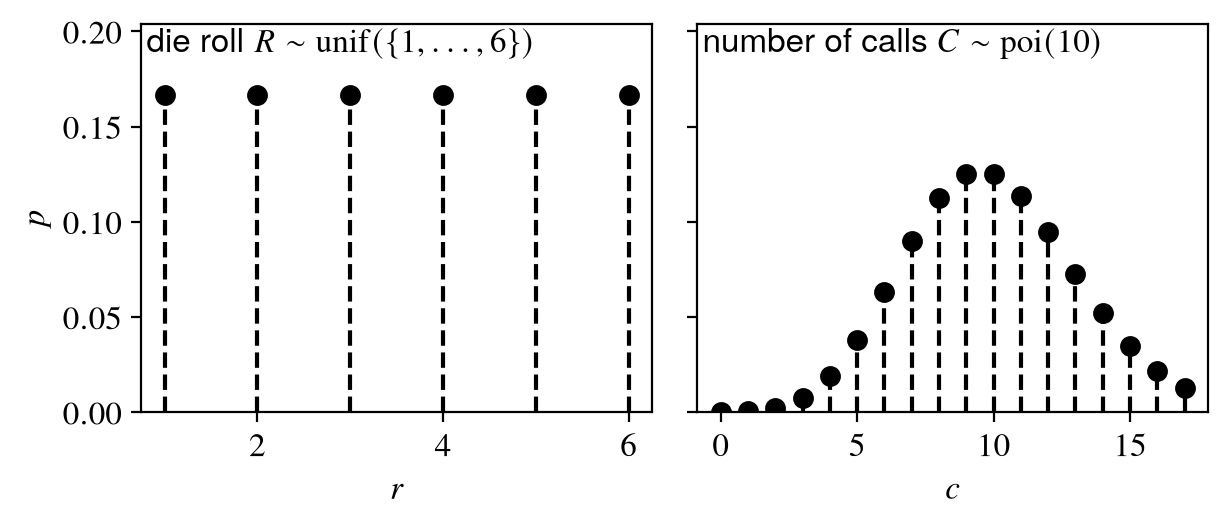

In [1]:
import numpy as np
from scipy.stats import poisson
from plotting import subplotgrid, plot_pmf, SLIDE_FIG_DIMS
from matplotlib import pyplot as plt

fig, ax = subplotgrid(['$r$', '$c$'], '$p$', intitles=[r'die roll $R \sim \mathrm{unif}(\{1, \dots, 6\})$', r'number of calls $C \sim \mathrm{poi}(10)$'], figsize=SLIDE_FIG_DIMS/2, xmargins=0.05, sharex=False, ylims=(0, 0.2))
plot_pmf(ax[0], np.arange(1, 7), lambda x: 1/6*np.ones_like(x))
plot_pmf(ax[1], np.arange(18), poisson(10).pmf)
plt.show()

### Continuous Random Variables

A random variable $X$ is called continuous if there is no element in its domain with a non-zero probability, i.e., if for all $x \in \mathcal X$,
$$
\mathbb{P}(X \in \{x\})=0 \enspace .
$$
This property is often unintuitive for beginners. It means that only events corresponding to non-trivial intervals, $[l, u] \subseteq \mathcal X$, and combinations of them have a non-zero probability. The distributions of such rando variables can then be represented by a **probability density function** or short *pdf* $p$ that describes the probability of all intervals via integration, i.e.,
$$
\mathbb{P}(X \in [l, u]) = \int_l^u p(x) \mathrm{d}x \enspace .
$$

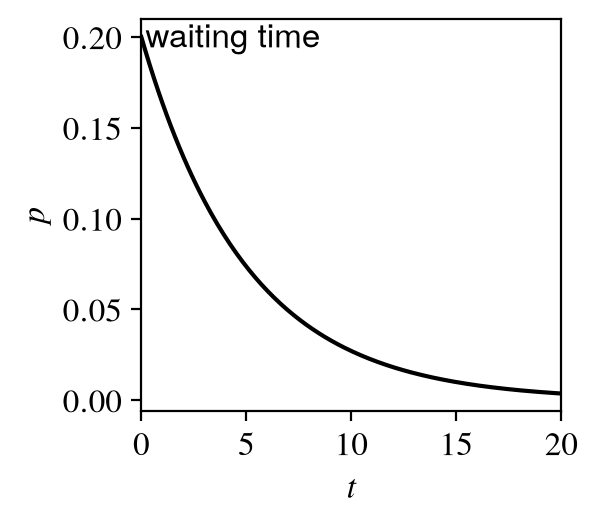

In [2]:
from scipy.stats import expon
from plotting import plotf

fig, ax = subplotgrid('$t$', '$p$', intitles=['waiting time'], figsize=(SLIDE_FIG_DIMS[0]/4, SLIDE_FIG_DIMS[1]/2))
plotf(ax, expon(scale=5).pdf, 0, 20, color='k')
plt.show()

### Cumulative Distribution Functions

$$
\mathbb P(X \leq x) = P(x)
$$

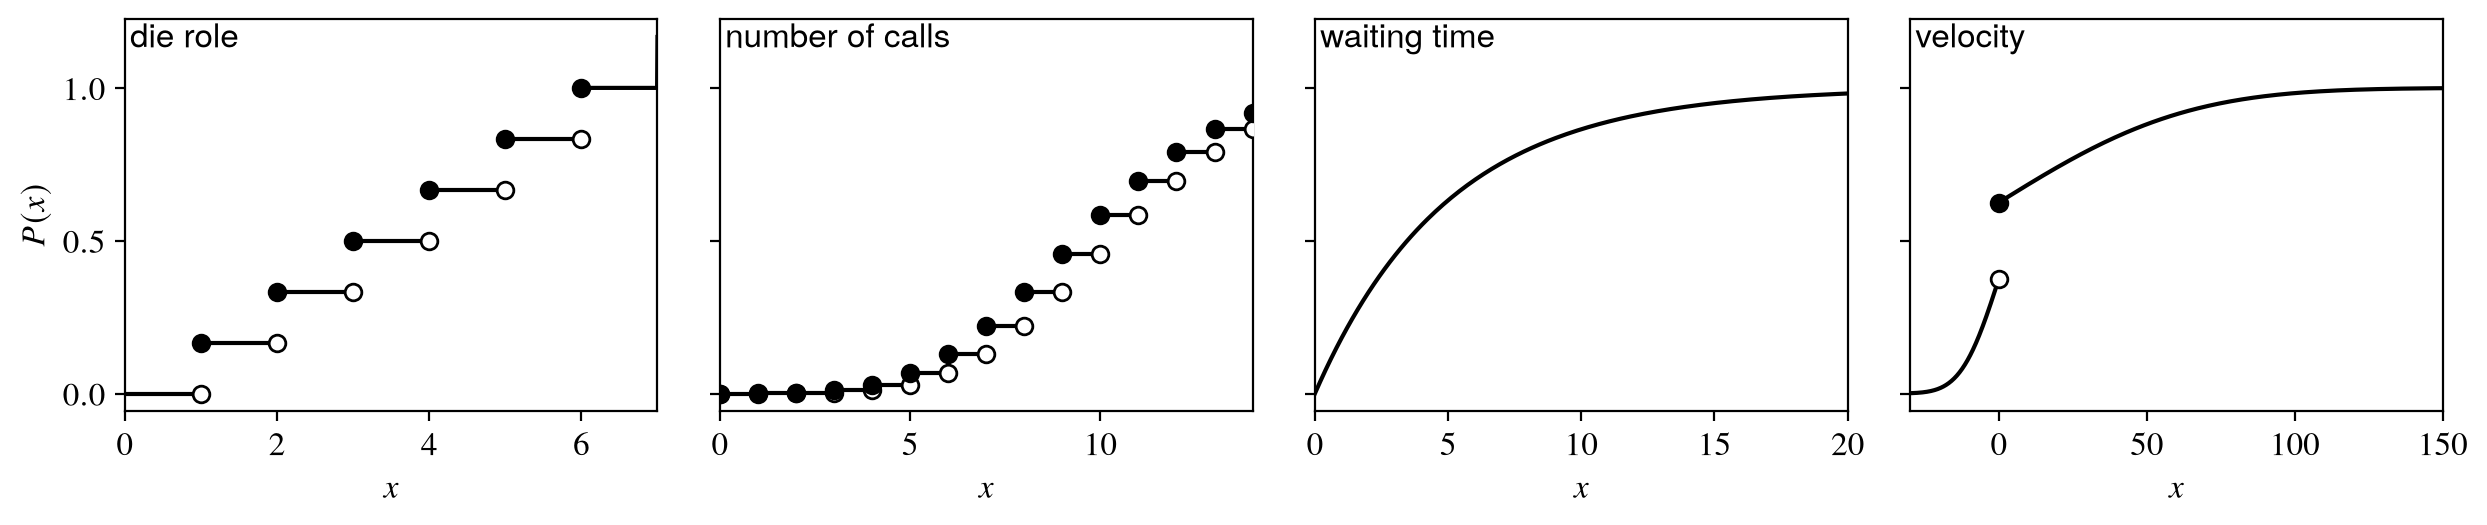

In [3]:
import numpy as np
from scipy.stats import poisson, expon, truncnorm
from plotting import subplotgrid, plotf, VERTICAL_HALF_SLIDE_DIMS

def dice_cdf(x):
    return np.floor(x)/6

def velocity_cdf(x):
    return (truncnorm(-20, 0, scale=10).cdf(x)*3/8 + truncnorm(0, 200, scale=50).cdf(x)*3/8 + (x >= 0)/4)

fig, ax = subplotgrid('$x$', '$P(x)$', ['die role', 'number of calls', 'waiting time', 'velocity'], sharex=False, figsize=VERTICAL_HALF_SLIDE_DIMS)
plotf(ax[0], dice_cdf, 0, 7, np.arange(1, 7), color='k')
plotf(ax[1], poisson(10).cdf, 0, 14, np.arange(0, 15), color='k')
plotf(ax[2], expon(scale=5).cdf, 0, 20, color='k')
plotf(ax[3], velocity_cdf, -30, 150, [0], color='k')

## Belief-based Decisions

Equipped with the concept of probabilities and their Bayesian interpretation, we can now define the **belief of an agent**, most generally, as probability function on the probability space $(\Omega, \mathcal{F})$ of the possible environments. However, usually it is enough to define a belief more simply as the joint distribution, e.g., in the form of the joint cdf $P$, of a number of random variables $Z_1, Z_2, \dots, Z_k$.

We postpone the two central question of 

1. what different beliefs an agent can actually hold (that is the question of the belief or **probability model**) and 
2. how to arrive at a reasonable belief based on observations of the environment (that is the topic of **inference**).

Instead we focus now on how to choose an action once a belief has been formed.

### Belief about Loss

The part of a belief of an agent about the environment that is relevant to decide on an action is captured in a distribution $P$ about the relevant unknown quantity $U$.
This provides in turn a belief about the loss $\ell(U, a)$ that an action $a \in A$ will incur.

In general, if a function $g$ is defined on the domain of a random variable $X$, then $g(X)$ is another random variable with a distribution that determined by the distribution of $X$. We also call $g(X)$ a **transformation** of $X$.

$$
\begin{aligned}
P_Y(y) &= \mathbb P(g(X) \leq y)\\
&= \mathbb P(X \leq g^{-1}(y))\\
&= P_X(g^{-1}(y))
\end{aligned}
$$

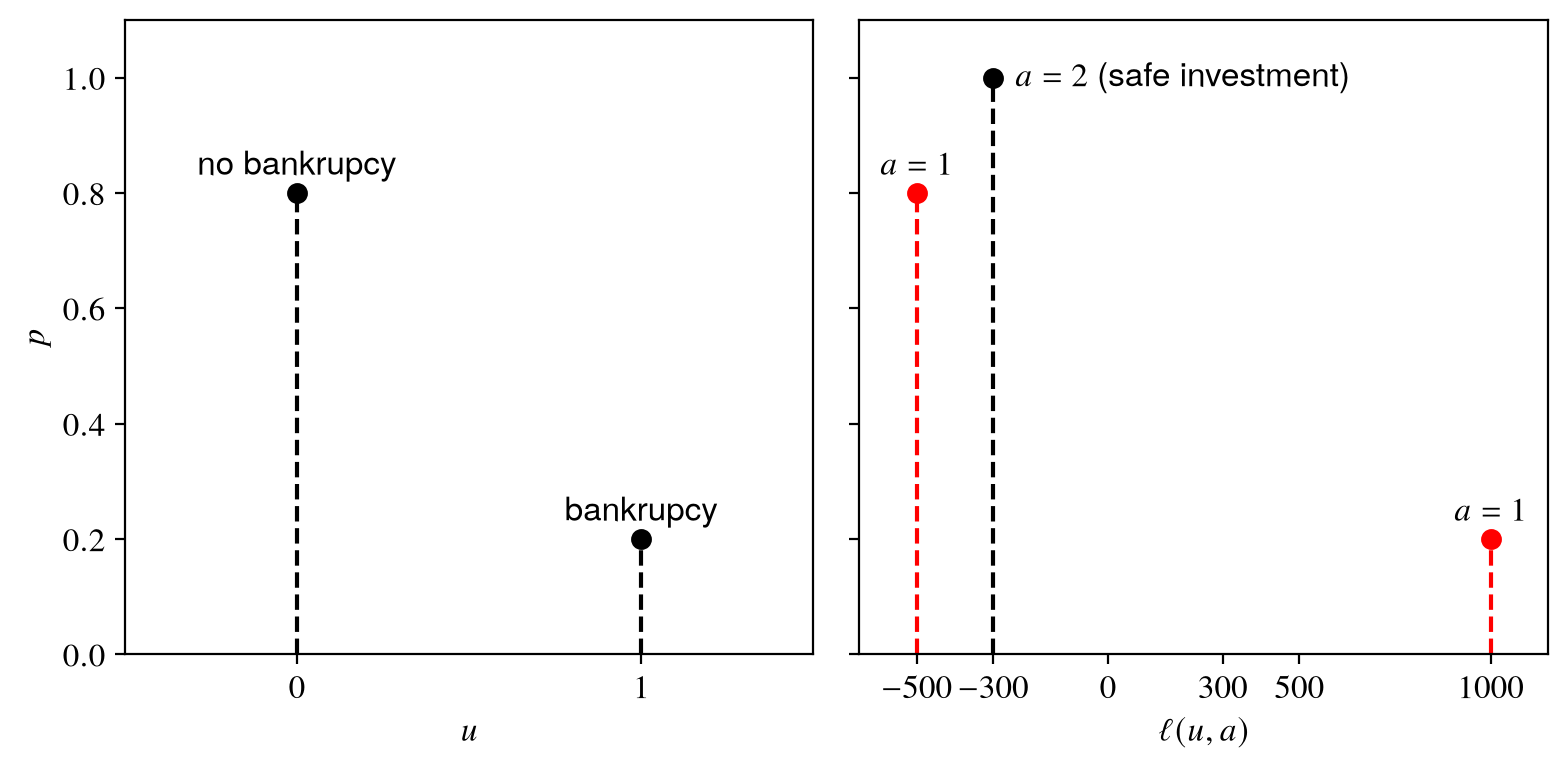

In [ ]:
from plotting import plot_pmf

fig, ax = subplotgrid(['$u$', r'$\ell(u, a)$'], '$p$', sharex=False)
plot_pmf(ax[0], np.array([0, 1]), lambda x: np.ones_like(x)*[0.8, 0.2])
plot_pmf(ax[1], np.array([-500, 1000]), lambda x: np.ones_like(x)*[0.8, 0.2], color='red')
plot_pmf(ax[1], np.array([-300]), lambda x: np.ones_like(x))
ax[0].annotate('no bankrupcy', (0, 0.8), xytext=(0, 4), textcoords='offset points', verticalalignment='bottom', horizontalalignment='center')
ax[0].set_xticks([0, 1])
ax[1].set_xticks([-500, -300, 0, 300, 500, 1000])
ax[0].annotate('bankrupcy', (1, 0.2), xytext=(0, 4), textcoords='offset points', verticalalignment='bottom', horizontalalignment='center')
ax[1].annotate('$a=1$', (-500, 0.8), xytext=(0, 4), textcoords='offset points', verticalalignment='bottom', horizontalalignment='center')
ax[1].annotate('$a=1$', (1000, 0.2), xytext=(0, 4), textcoords='offset points', verticalalignment='bottom', horizontalalignment='center')
ax[1].annotate('$a=2$ (safe investment)', (-300, 1), xytext=(8, 0), textcoords='offset points', verticalalignment='center', horizontalalignment='left')
ax[0].set_xlim(-0.5, 1.5)
ax[1].margins(x=0.1)
ax[1].set_ylim(0, 1.1)
plt.show()

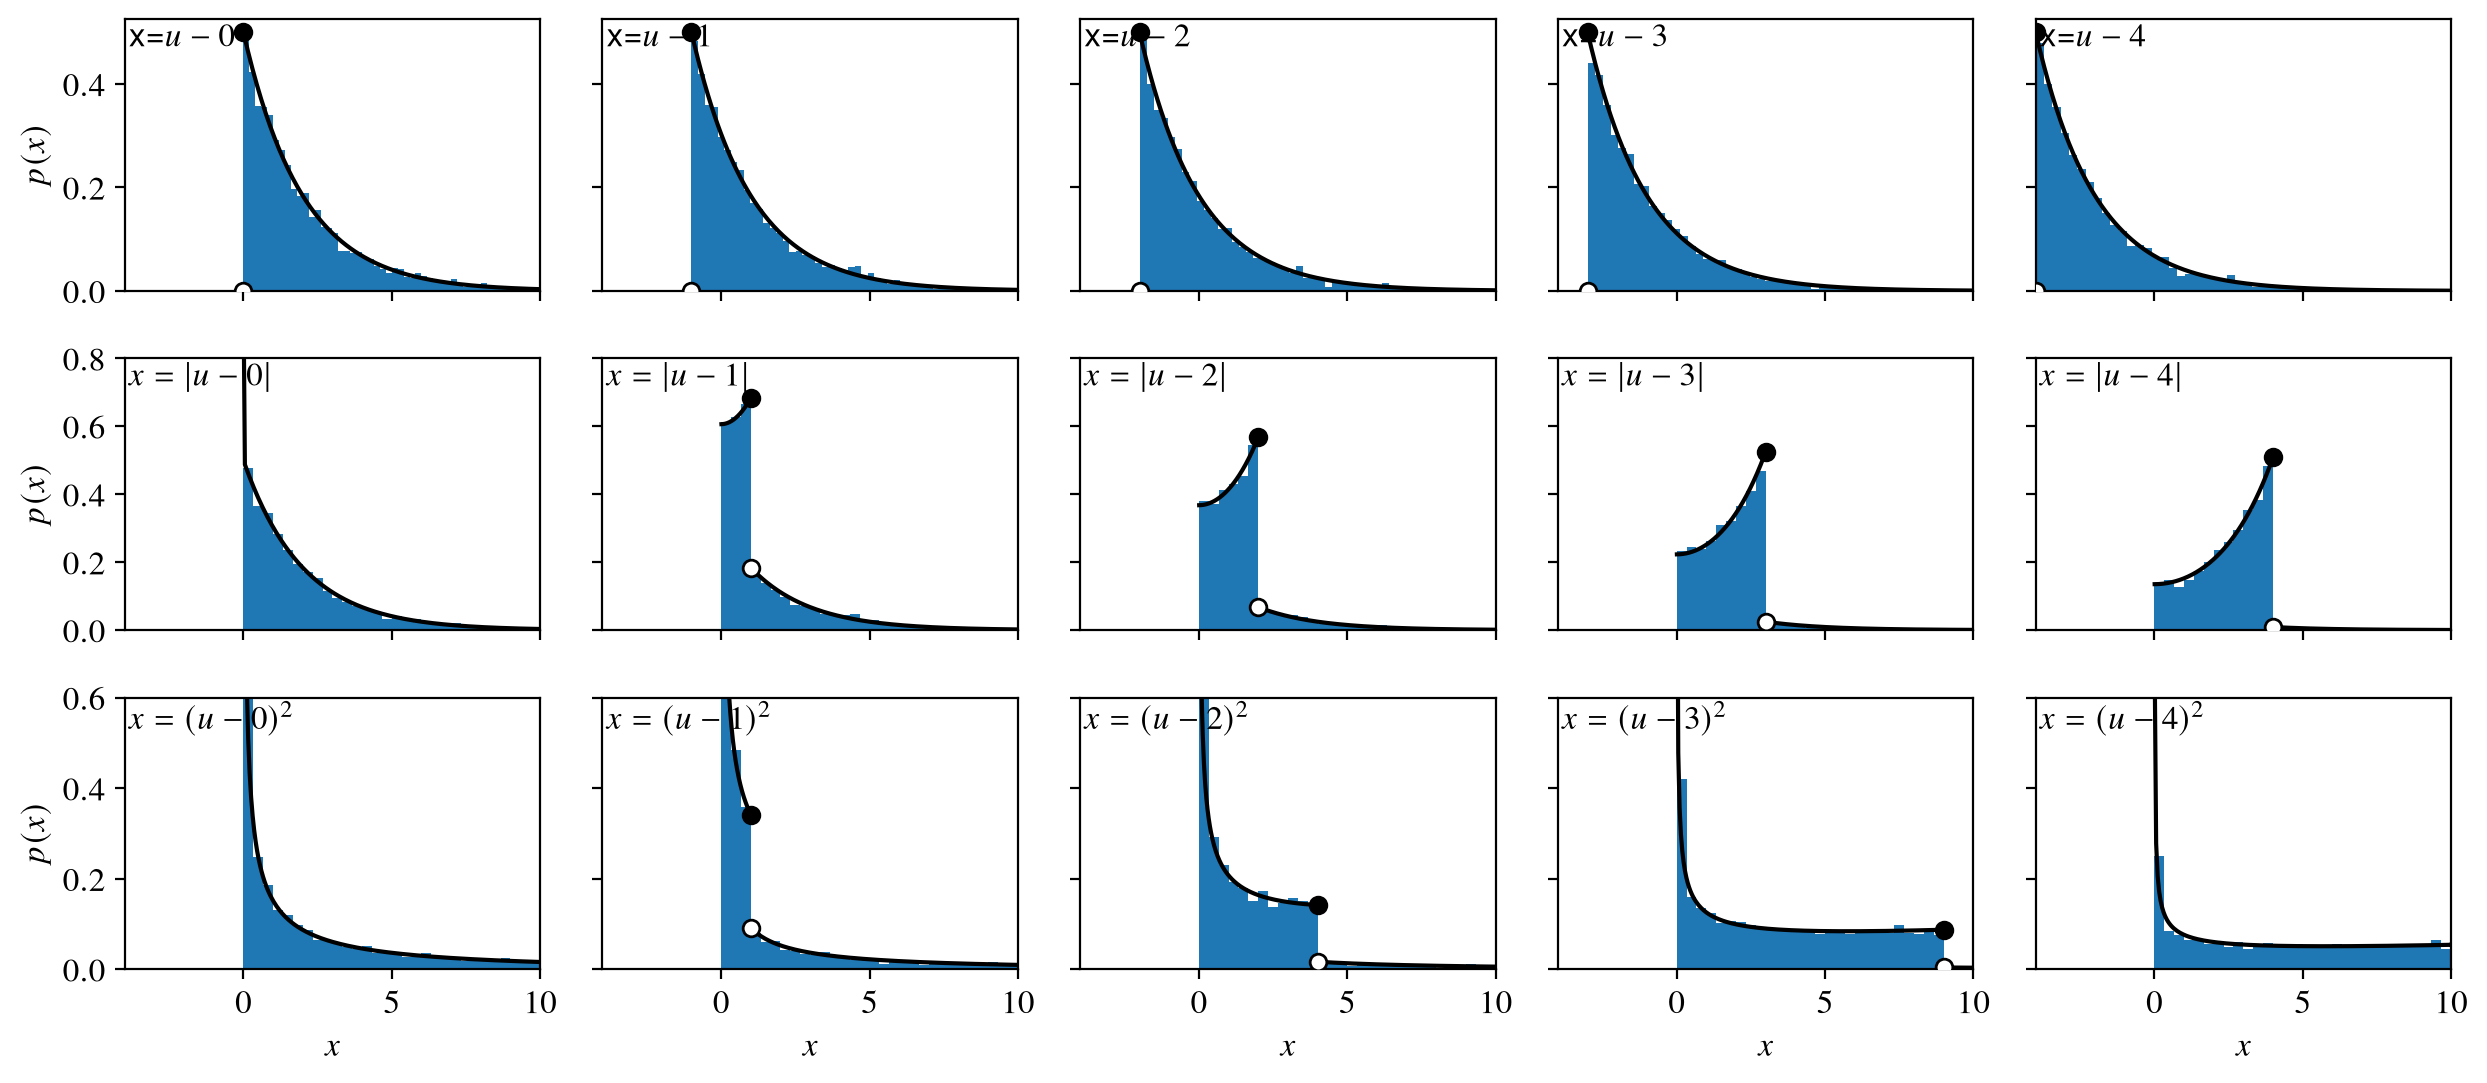

In [104]:
from plotting import histo

lam = 1/2
actions = [0, 1, 2, 3, 4]
fig, ax = subplotgrid(r'$x$', '$p(x)$', 
                      [[f'x=$u-{a}$' for a in actions], 
                        [f'$x=|u-{a}|$' for a in actions],
                        [f'$x=(u-{a})^2$' for a in actions]],
                        sharex=True, sharey='row', figsize=SLIDE_FIG_DIMS)

for j, a in enumerate(actions):
    err_dist = expon(scale=1/lam, loc=-a)
    data = err_dist.rvs(size=5000)
    histo(ax[0][j], data, bins=50, range=(-a, 10))
    histo(ax[1][j], np.abs(data), bins=30, range=(0, 10))
    histo(ax[2][j], data**2, bins=30, range=(0, 10))
    plotf(ax[0][j], err_dist.pdf, -a, 10, discont=[-a], color='k', label=f'$a={a}$')
    if a > 0:
        plotf(ax[1][j], lambda loss: (err_dist.pdf(loss)+err_dist.pdf(-loss)), 0.01, 10, discont=a, sides='right', color='k')
        plotf(ax[2][j], lambda loss: (err_dist.pdf(loss**0.5)+err_dist.pdf(-loss**0.5))/(2*loss**0.5), 0.01, 10, discont=a**2, sides='right', color='k')
    else:
        plotf(ax[1][j], lambda loss: (err_dist.pdf(loss)+err_dist.pdf(-loss)), 0, 10, color='k')
        plotf(ax[2][j], lambda loss: (err_dist.pdf(loss**0.5)+err_dist.pdf(-loss**0.5))/(2*loss**0.5), 0.01, 10, color='k')
ax[1][0].set_ylim(0, 0.8)
ax[2][0].set_ylim(0, 0.6)
ax[0][0].set_xlim(-4, 10)
plt.show()

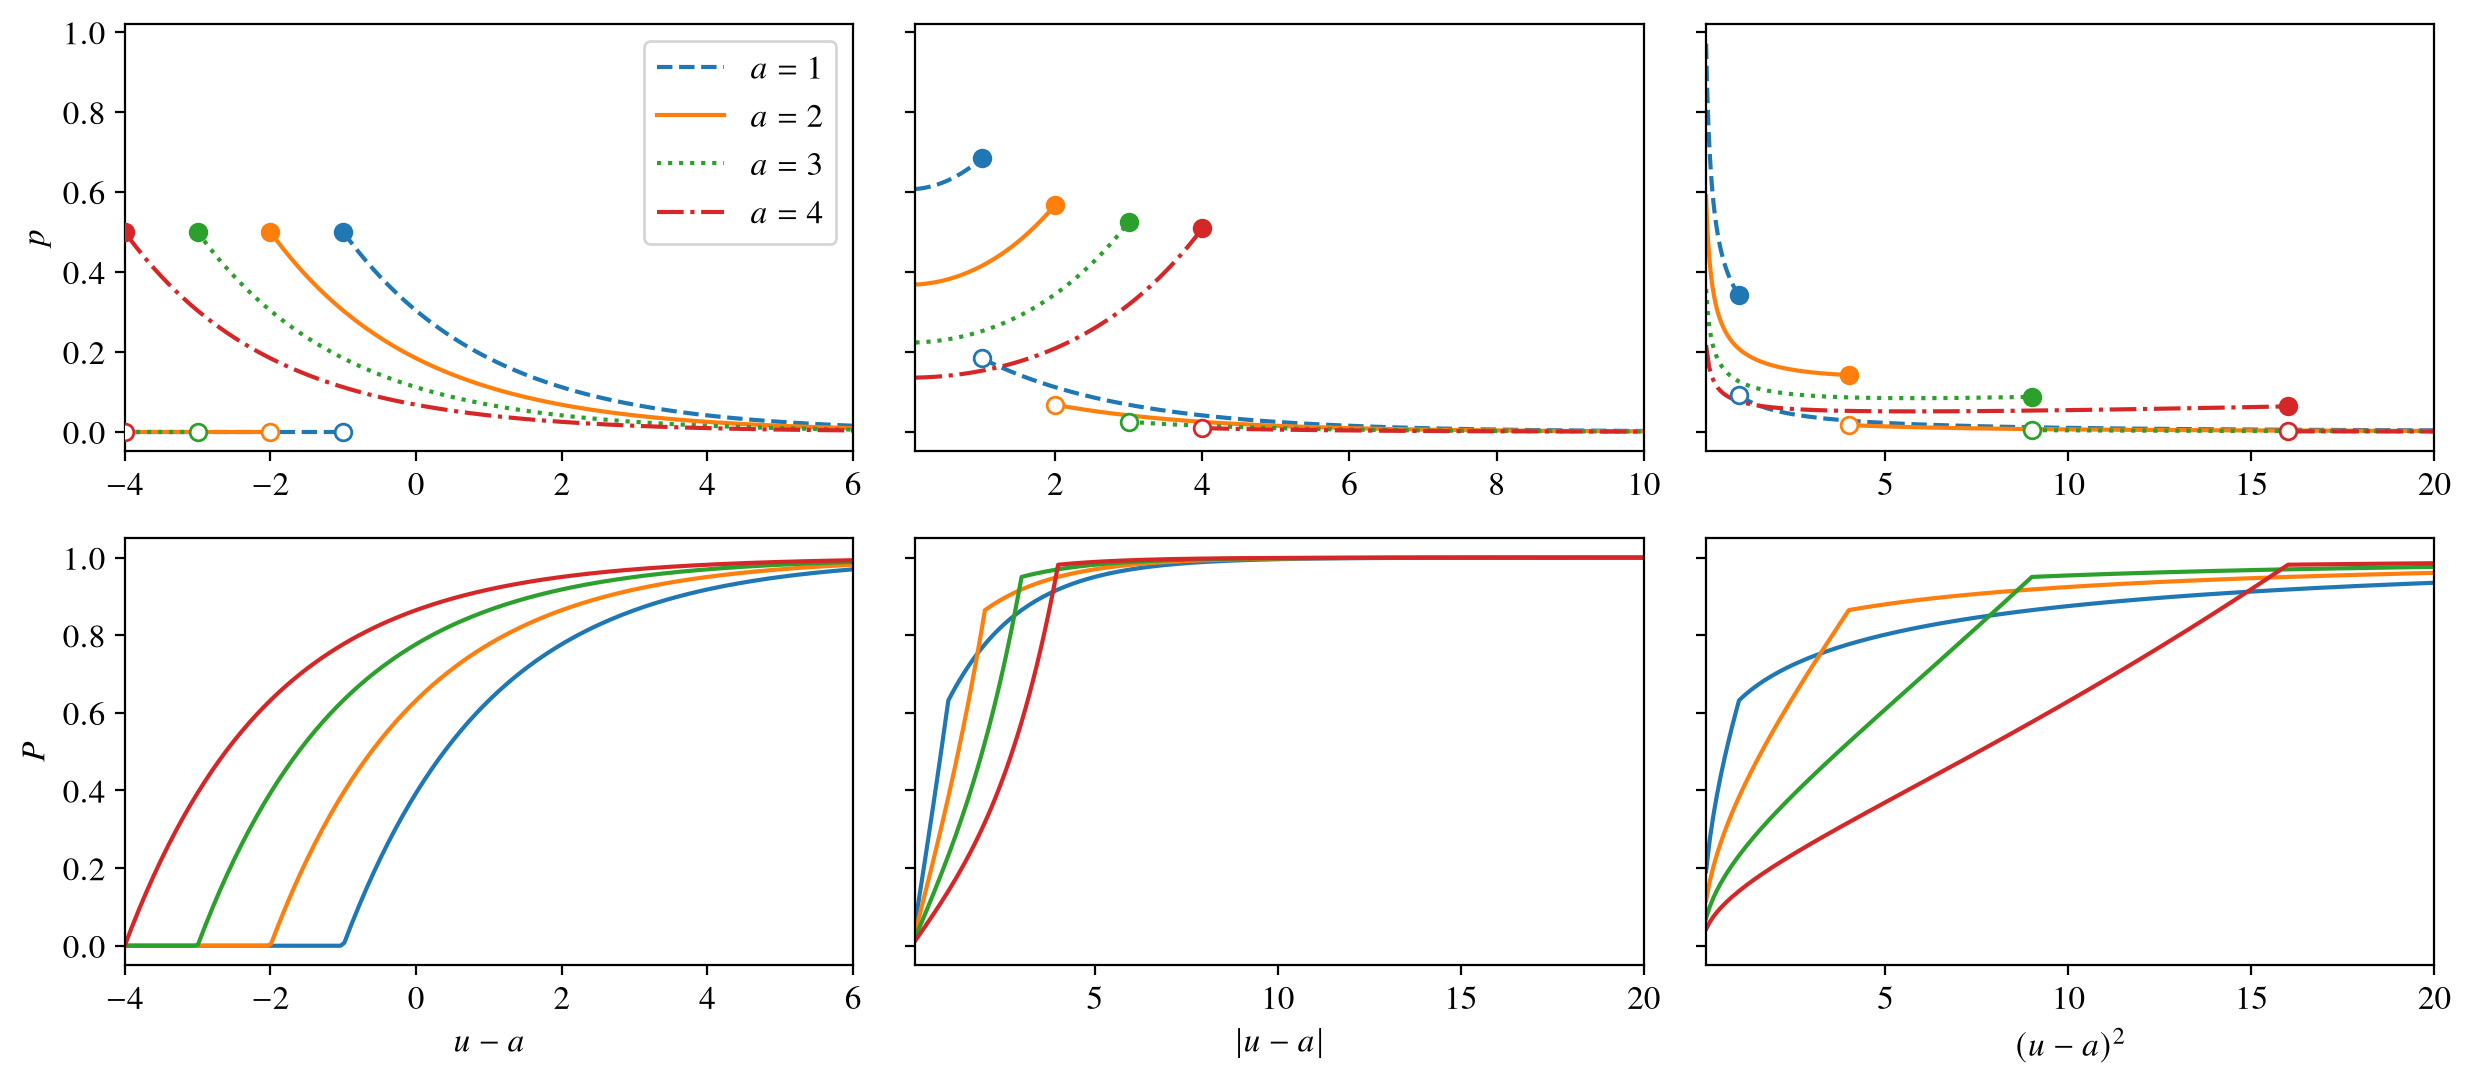

In [16]:
lam = 1/2
actions = [1, 2, 3, 4]
lss = ['--', '-', ':', '-.']

us = np.linspace(-4, 6, 200)
errs = us - 1
ls = np.linspace(0.1, 20, 200)
fig, ax = subplotgrid(['$u-a$', '$|u-a|$', r'$(u-a)^2$'], ['$p$', '$P$'], sharex=False, sharey='row', figsize=SLIDE_FIG_DIMS)
# ax[0][0].plot(us, expon(scale=1/lam).pdf(us))
for a, l_sty in zip(actions, lss):
    err_dist = expon(scale=1/lam, loc=-a)
    plotf(ax[0][0], err_dist.pdf, -4, 6, discont=[-a], ls=l_sty, label=f'$a={a}$')
    plotf(ax[0][1], lambda loss: (err_dist.pdf(loss)+err_dist.pdf(-loss)), 0.1, 10, discont=a, sides='right', ls=l_sty)
    plotf(ax[0][2], lambda loss: (err_dist.pdf(loss**0.5)+err_dist.pdf(-loss**0.5))/(2*loss**0.5), 0.1, 20, discont=a**2, sides='right', ls=l_sty)
    ax[1][0].plot(us, expon(scale=1/lam, loc=-a).cdf(us))
    ax[1][1].plot(ls, (expon(scale=1/lam, loc=-a).cdf(ls) - expon(loc=-a, scale=1/lam).cdf(-ls)))
    ax[1][2].plot(ls, (expon(scale=1/lam, loc=-a).cdf(ls**0.5) - expon(loc=-a, scale=1/lam).cdf(-ls**0.5)))
ax[0][0].legend()
plt.show()

In [128]:
np.log(2)*2

np.float64(1.3862943611198906)

### Expectations

$$
\mathbb E(X) = \int_\mathcal{X} x \, \mathrm{d}P(x)
$$

### Decisions based on Expected Loss

Now assume that an agent has a belief about the environment captured in the joint probability distribution with cdf $P$ of a random vector $Z=(Z_1, \dots, Z_k)$ that contains all quantities relevant for the definition of the loss function that we can then write as $\ell(Z, a)$. A straightforward decision principle is then to choose an action $a$ based on its **expected loss** $L(a)$:

$$
L(a) = \mathbb{E}(\ell(Z, a))=\int_z \ell(z, a) \mathrm d P(z) = \int_{z_1} \dots \int_{z_k} \ell(z, a) \mathrm d P(z_k) \dots \mathrm d P(z_k) \enspace .
$$

In particular, if it exists, one can choose an action $a^*$ of minimal expected loss, i.e.,
$$
L(a^*) = \min \{L(a) \! : \, a \in A\}
$$

An extension of this simple criterion (that takes into account observations to form belief) will be called **Conditional Bayesian Decision Principle** (Berger, 1985, Ch. 1.5.1) or simply **Maximum Expected Utility Principle** (Kochenderfer, 2022, Ch. 6.4). As we will discuss in due time, there are other  criteria that can lead to very different decisions.

### Simple Example Revisited

Recall our example in which an agent can choose to invest $\$1000$ either in

1. **Action $a_1$:** bonds of a company that return $\$1500$ in two years if the company did not go bankrupt or nothing if it did; or
2. **Action $a_2$:** a safe investment that surely returns $\$1300$ 

Let us define a binary variable $Z$ that indicates whether the company goes bankrupt in the next two years, i.e.,
$$
Z =
\begin{cases}
1 &, \text{if company goes bankrupt}\\
0 &, \text{otherwise}
\end{cases} \enspace .
$$

With this we can rewrite the loss function as

$$
\begin{aligned}
\ell(Z, a_1)&=1000\,Z - 500\,(1-Z)\\
\ell(Z, a_2)&=-300
\end{aligned}\enspace .
$$

Since $Z$ is a binary variable it is governed by a Bernoulli distribution, say with parameter $\theta$, i.e.,
$$
Z \sim \mathrm{Ber}(\theta) \enspace .
$$
That means that $\theta = \Pr(Z=1)$ is the degree to which the agent beliefs that the company will go bankrupt.

**Questions:**

1. Assuming the agent is completely undecided whether bankruptcy will occur ($\theta=0.5$), what is the expected loss of $L(a_1)$ of action $a_1$?
2. Further in this case, which action would the agent choose according to the expected loss decision principle?
3. For what values of $\theta$ will the agent choose what action (determine graphically)?

$$
\begin{aligned}
L(a_1) &= (-500)\,\theta+(1-\theta)\, 1000 = 1000 - 1500\,\theta\,\\
L(a_2) &= -300
\end{aligned}
$$

[[-500 -300]
 [1000 -300]]


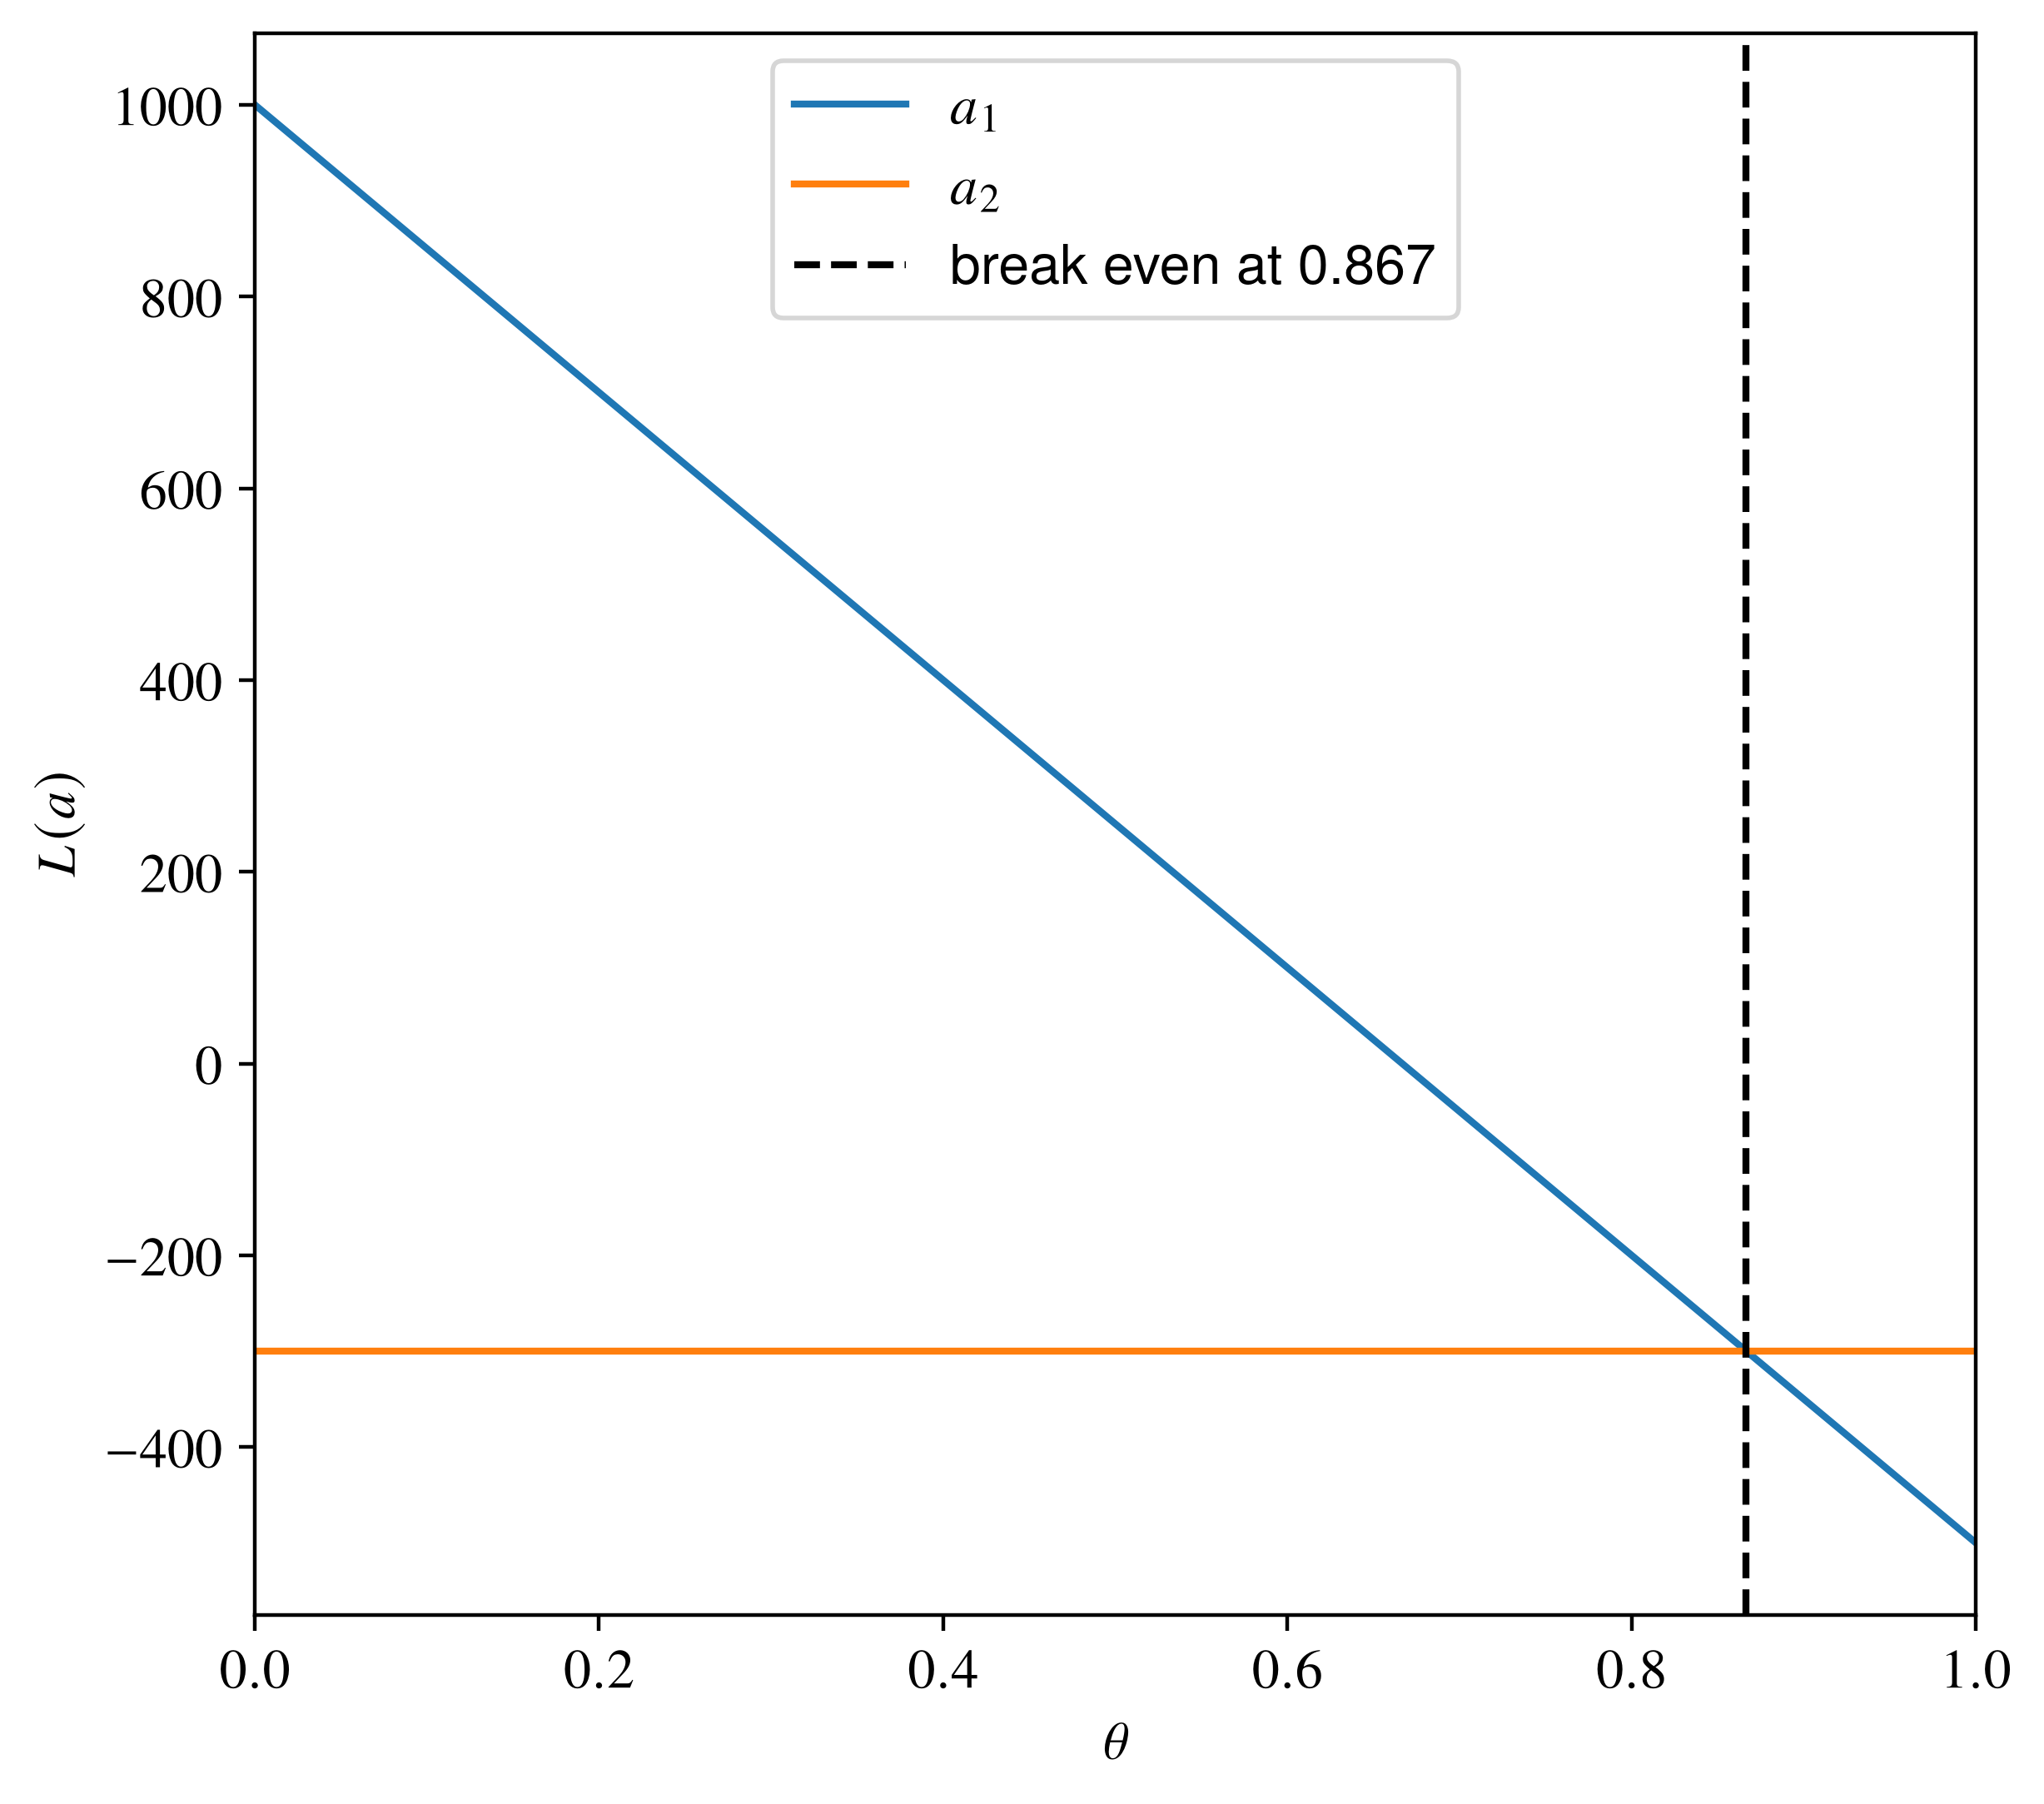

In [4]:
%config InlineBackend.figure_format = 'retina'

from matplotlib import pyplot as plt
from plotting import subplotgrid, HALF_SLIDE_DIMS
import numpy as np
from IPython.display import display

loss_matrix = np.array([[-500, -300], [1000, -300]])
print(loss_matrix)

def expected_loss(a, theta):
    return loss_matrix[0, a]*theta + (1-theta)*loss_matrix[1, a]

thetas = np.linspace(0, 1, 200)
fig, ax = subplotgrid(r'$\theta$', '$L(a)$', figsize=HALF_SLIDE_DIMS)
ax.plot(thetas, expected_loss(0, thetas), label='$a_1$')
ax.plot(thetas, expected_loss(1, thetas), label='$a_2$')
ax.axvline(13/15, linestyle='--', color='k', label=f'break even at {13/15:.3f}')
ax.legend()
plt.savefig('output/investment_expected_loss.pdf', bbox_inches=0, dpi=300)
display(fig, metadata={'image/png': {'width': '75%'}})
plt.close()

## Scenario: Production Volume

### Setting and Loss Function

A company has to decide on a relative production volume $a \in [0, 1]$ for a new product. Here, $a$ is the fraction of a known market size $s$ of product units, i.e., the overall number of units for which there is a demand on the market. This means that choosing production volume $a$ corresponds to producing $sa$ units of the product. 

The *markup* of the product, i.e., the ratio of profit (selling price - cost) to cost is assumed to be $0.5$.

**Question: What aspect of the environment / random variable does the utility/loss of an action $a \in A=[0, 1]$ depend on?**

The *market capture* of the new product $Z \in [0, 1]$ describing the number of units $sZ$ that will be sold at the determined price.

**Question: What is a reasonable loss function in terms of $z \in [0, 1]$ and $a \in [0, 1]$?**

Hints:

1. Consider the loss separately for the two cases of under-production $a \leq z$ and over-production $a > z$.
2. You can simplify the function by considering as loss the differences between the optimal action and the action chosen.

Answer:
$$
\ell(z, a) =
\begin{cases}
z - a & \text{, } z \geq a \\
2(a - z) & \text{, otherwise} 
\end{cases}
$$

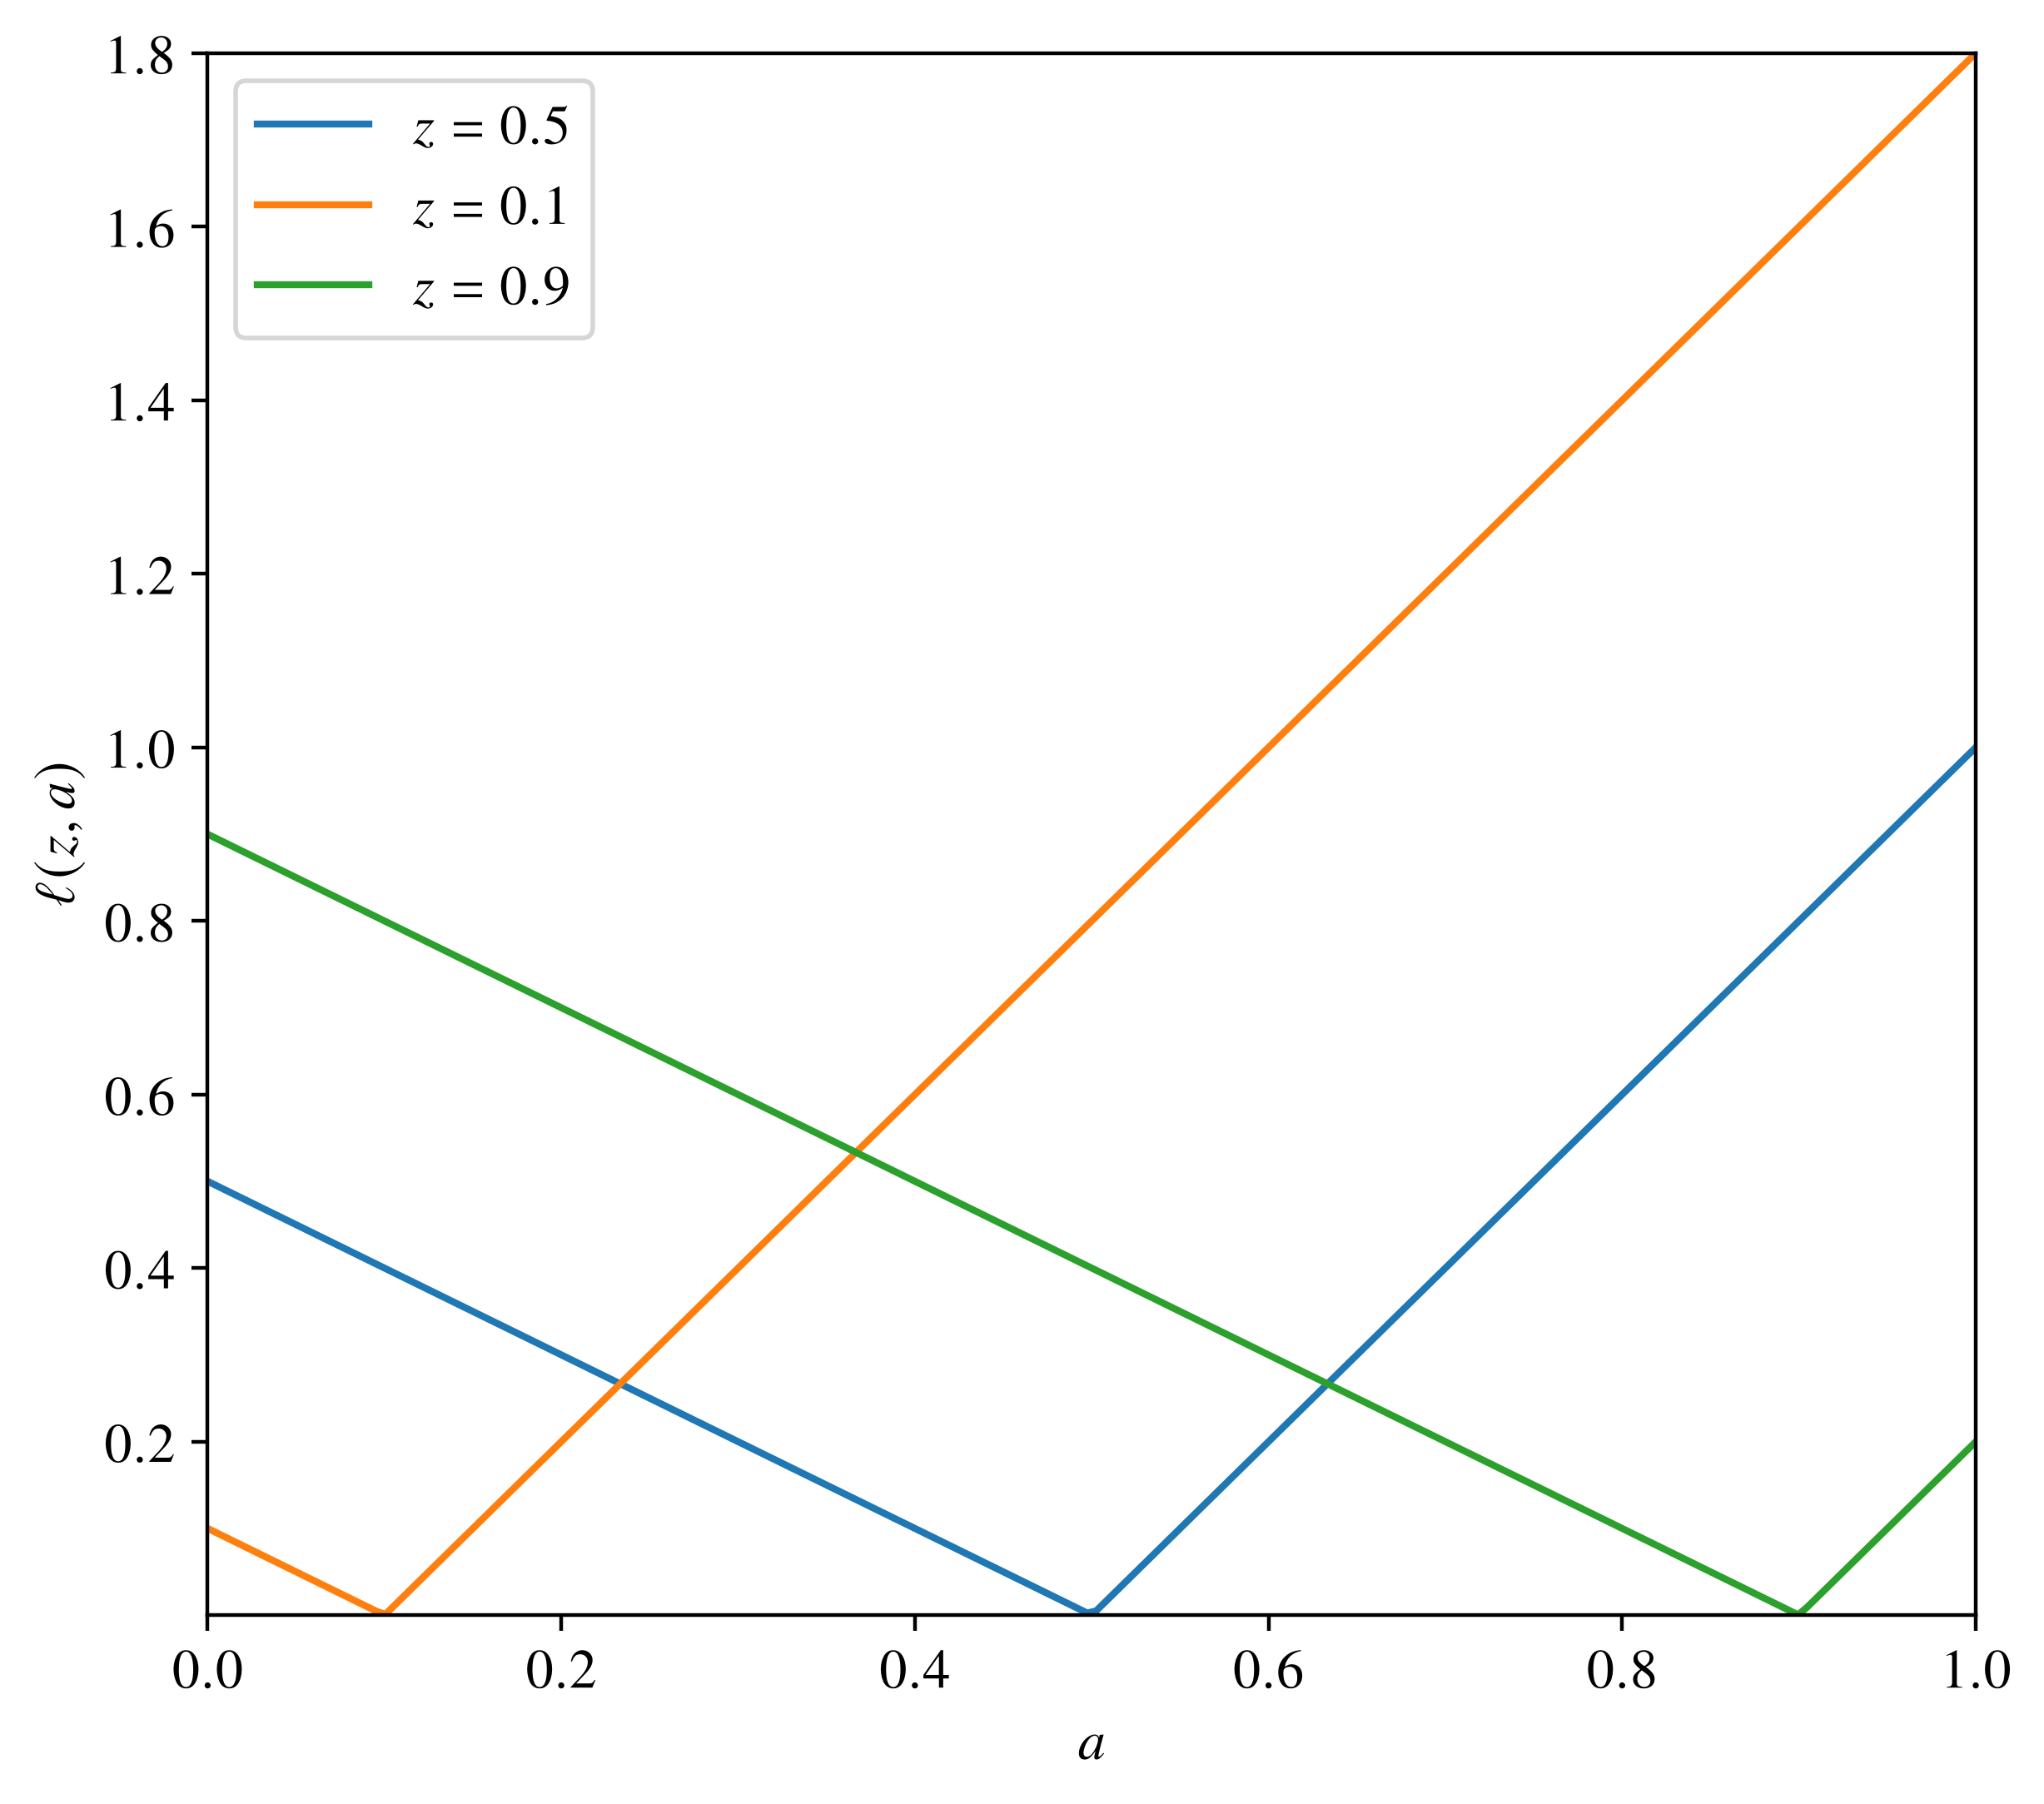

In [7]:
from matplotlib import pyplot as plt
import numpy as np

def loss(z, a):
    return (z >= a)*(z - a) + (z < a)*2*(a - z)

fig, ax = subplotgrid('$a$', r'$\ell(z,a)$', ymargins=0, figsize=HALF_SLIDE_DIMS)
xs = np.linspace(0, 1, 200, endpoint=True)
ax.plot(xs, loss(0.5, xs), label=r'$z=0.5$')
ax.plot(xs, loss(0.1, xs), label=r'$z=0.1$')
ax.plot(xs, loss(0.9, xs), label=r'$z=0.9$')
plt.legend()
display(fig, metadata={'image/png': {'width': '75%'}})
plt.close()

### Agnostic Belief

Since the loss in the production volume problem depends on the unknown market capture $Z \in [0, 1]$ of the product, we have to assume a belief about that variable to determine what is the best action. Let us start with a completely agnostic belief, i.e., one that does not favour any range of possible values over another. This is represented by **continuous uniform distribution** over the interval $[0, 1]$, i.e., the assumption that $Z \sim \mathrm{Unif}(0, 1)$, or in other words that
$$
\Pr(Z \in [a, b]) = b - a
$$
for $0 \leq a \leq b \leq 1$.

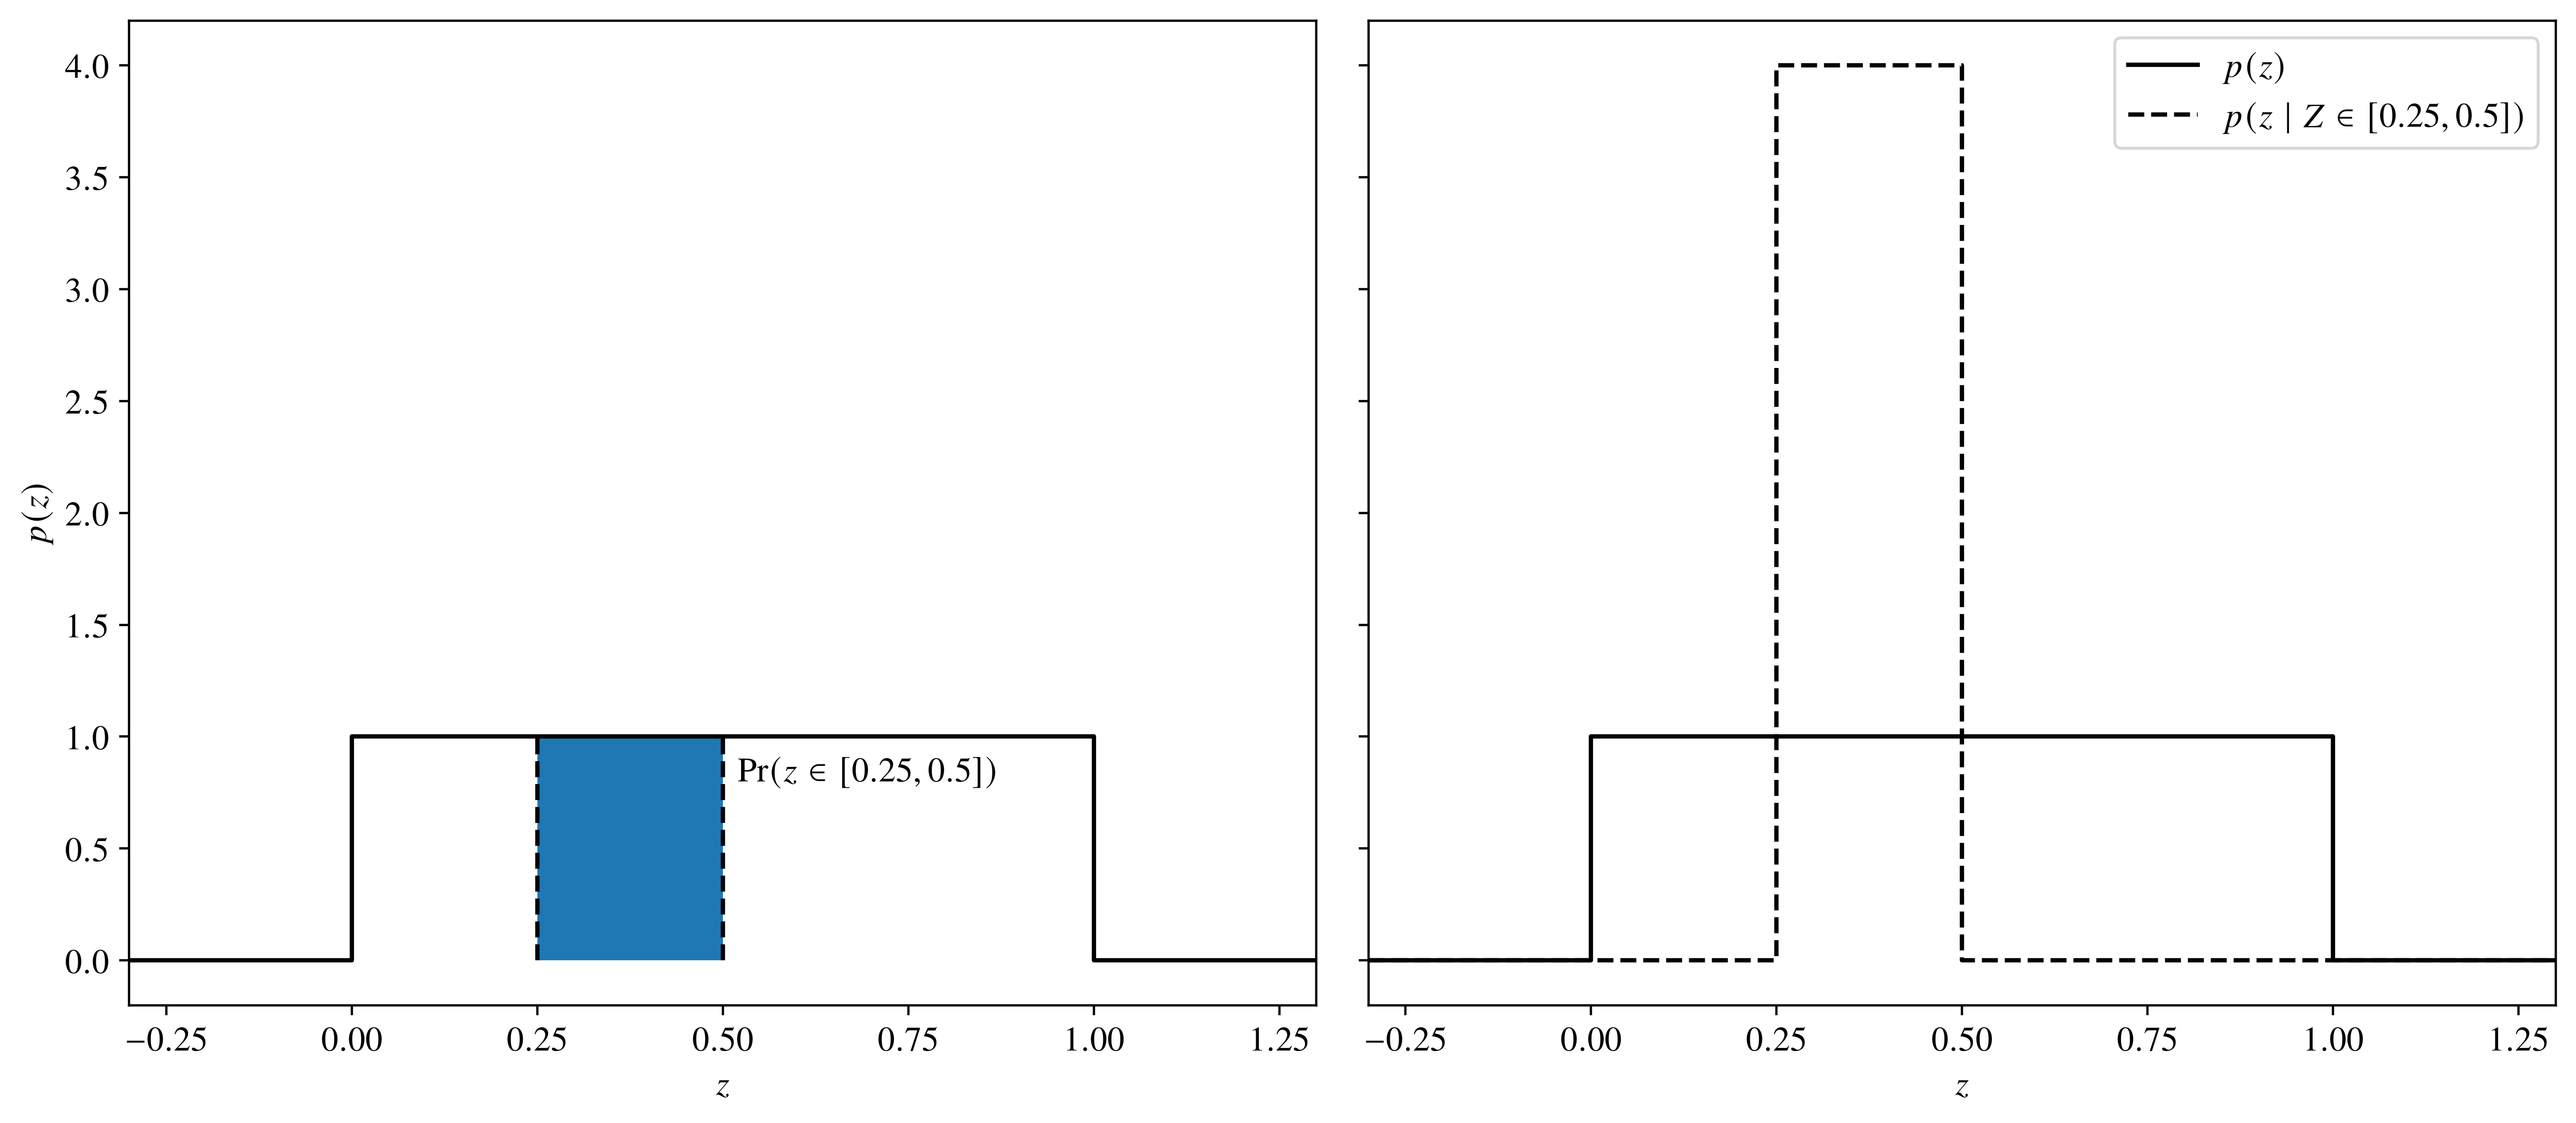

In [13]:
from plotting import SLIDE_FIG_DIMS
# fig, ax = plt.subplots(1, 2, figsize=(12, 4), tight_layout=False)
fig, ax = subplotgrid('$z$', '$p(z)$', rows=1, cols=2, figsize=SLIDE_FIG_DIMS)
ax[0].plot([-0.3, 0, 0, 1, 1, 1.3], [0, 0, 1, 1, 0, 0], color='k')
ax[0].fill_between([0.25, 0.5], [1, 1], label=r'$\Pr(z \in [0.25, 0.5])$')
ax[0].vlines([0.25, 0.5], 0, 1, linestyles='--', colors='k')
ax[0].text(0.52, 0.8, r'$\Pr(z \in [0.25, 0.5])$', horizontalalignment='left', fontsize=12)
ax[0].set_xticks([-0.25, 0, 0.25, 0.5, 0.75, 1, 1.25])

ax[1].plot([-0.3, 0, 0, 1, 1, 1.3], [0, 0, 1, 1, 0, 0], color='k', label='$p(z)$')
ax[1].plot([-0.3, 0.25, 0.25, 0.5, 0.5, 1.3], [0, 0, 4, 4, 0, 0], color='k', ls='--', label=r'$p(z \mid Z \in [0.25, 0.5])$')
ax[1].legend()
plt.show()
# display(fig, metadata={'image/png': {'width': '100%'}})
# plt.close()

### Expected Loss

Using the definition of our loss function and the law of total expectation, we can decompose the Bayesian expected loss as
$$
\begin{aligned}
L(a) &= \bold{E}(\ell(Z, a))\\
&= \bold{E}(Z - a \mid Z \geq a)\Pr(Z \geq a) + \bold E(2(a-Z) \mid Z < a)\Pr(Z < a)\\
&= (\bold{E}(Z \mid Z \geq a)-a)\Pr(Z \geq a) + 2(a-\bold E(Z \mid Z < a))\Pr(Z < a) \enspace .
\end{aligned}
$$

Facts:

1. $\Pr(Z \geq a) = 1-a$
2. $\Pr(Z < a) = a$
3. $\bold{E}(Z \mid Z \geq a)=(1+a)/2$
4. $\bold E(Z \mid Z < a)=a/2$

$$
\begin{aligned}
L(a) &= (1-a)\left(\frac{1+a}{2} - a\right) + 2a\left(a - \frac{a}{2}\right)\\
&= (1-a)\frac{1-a}{2} + a^2\\
&= \frac{3}{2}a^2 - a + \frac{1}{2}
\end{aligned}
$$


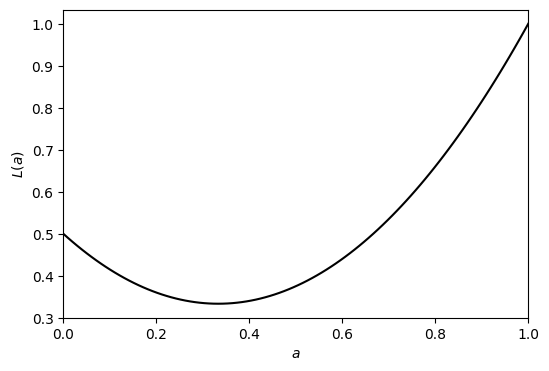

In [63]:
a = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(a, 3*a**2/2 - a + 0.5, color='k')
ax.margins(x=0)
ax.set_xlabel('$a$')
ax.set_ylabel('$L(a)$')
plt.show()

### Optimal Action

With the analytical form of the expected loss we can now find the optimal action by forming the derivative and setting it to 0. The derivative is:
$$
\frac{\mathrm d L(a)}{\mathrm d a} = \frac{\mathrm d}{\mathrm d a} \left (\frac{3}{2}a^2 - a + \frac{1}{2}\right) =3a - 1
$$

Setting to 0 and solving for $a$ yields:
$$
a^* = \frac{1}{3}
$$

## Summary

1. To decide on an action in an uncertain environment, an agent needs... a loss function $\ell(z, a)$ and a belief about the relevant variable(s) of the environment $Z$
2. Belief can be represented as... a probability distribution $P(z)$
3. One decision principle is then to choose the action with... the lowest expected loss $L(a)=\bold E \ell(Z, a)$

### Narrower belief

Using the definition of our loss function, we can decompose the Bayesian expected loss as
$$
\begin{aligned}
L(a) &= \bold{E}(\ell(\theta, a))\\
&= \bold{E}(\theta - a \mid \theta \geq a)\Pr(\theta \geq a) + \bold E(2(a-\theta) \mid \theta < a)\Pr(\theta < a) \enspace .
\end{aligned}
$$

Let us assume we believe $\theta \sim \mathrm{Unif}(0.1, 0.2)$. Then we can further analyse the above expression via a case distinction on $a$. 

**Case $a < 0.1$**: 

This case is simple, because it implies $\Pr(\theta \geq a)=1$, $\Pr(\theta < a)=0$, and $\bold{E}(\theta \mid \theta \geq a)=\bold E(\theta)=0.15$. If follows that $L(a)=0.15 - a$.

**Case $a > 0.2$**:

This case is similarly simply, because it implies $\Pr(\theta \geq a)=0$, $\Pr(\theta < a)=1$, and again $\bold{E}(\theta \mid \theta < a)=\bold E(\theta)=0.15$. It follows that $L(a)=2(a - \bold E(\theta \mid a > \theta))=2a - 0.3$.

**Case $0.1 \leq a \leq 0.2$**:

This final case is a bit more complicated, but still managable. 

1. $\Pr(\theta \geq a) = 10(0.2 - a)$
2. $\Pr(\theta < a) = 10(a - 0.1)$
3. $\Pr(\theta \mid \theta \geq a) = (0.2 - a)/2$
4. $\Pr(\theta \mid \theta < a)=(a - 0.1)/2$

It follows that 
$$
\begin{aligned}
L(a) &= 5(0.2 - a)^2 + 10(a-0.1)^2\\
&= 5a^2 + 0.2 - 2a + 10a^2 + 0.1 - 2a\\
&= 15a^2 - 4a + 0.3
\end{aligned}
$$

Summarising the three different cases yields:
$$
L(a) =
\begin{cases}
0.15 - a & \text{, } a < 0.1\\
15a^2 - 4a + 0.3 & \text{, } 0.1 \leq a \leq 0.2\\
2a - 0.3 & \text{, otherwise}
\end{cases}
$$

Further, with basic calculus we can show that the optimal action is $a^*=2/15$ with a Bayesian expected loss of $L(a^*)=1/30$

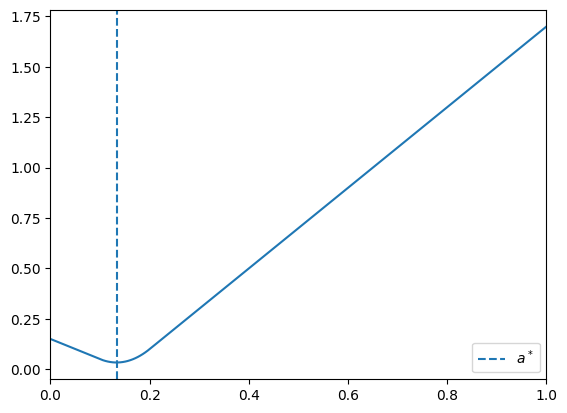

In [33]:
def bayes_expected_loss(a):
    return (0.15-a)*(a<0.1) + (15*a**2 - 4*a + 0.3)*((a >= 0.1) & (a<= 0.2)) + (2*a-0.3)*(a>0.2)

plt.plot(xs, bayes_expected_loss(xs))
plt.axvline(2/15, ls='--', label='$a^*$')
plt.margins(x=0)
plt.legend()
plt.show()